In [1]:
from datetime import datetime as dt
from typing import Tuple, Optional, Dict
from dfply import *
from sklearn.ensemble import RandomForestClassifier
from sklearn.mixture import BayesianGaussianMixture
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs
from scipy.stats import norm
from scipy import stats
import pandas as pd
import numpy as np
import math, os, uuid, sys, requests, re, time, statistics
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import chi2_contingency


Open Tables

In [2]:
file_name =  "DATA_RESPONSES.xlsx"
# Responses
RESPONSES = pd.read_excel(file_name, sheet_name = "RESPONSES")
RESPONSES = pd.DataFrame(RESPONSES)
#Concepts
CONCEPTS = pd.read_excel(file_name, sheet_name = "CONCEPTS")
CONCEPTS = pd.DataFrame(CONCEPTS)
#Questions
QUESTIONS = pd.read_excel(file_name, sheet_name = "QUESTIONS")
QUESTIONS = pd.DataFrame(QUESTIONS)
# Surveys
SURVEYS = pd.read_excel(file_name, sheet_name = "SURVEYS")
SURVEYS = pd.DataFrame(SURVEYS)


Create Data Model

In [3]:
QUESTIONS = QUESTIONS >> left_join(CONCEPTS, by='CONCEPT_KEY') 
QUESTIONS = QUESTIONS >> left_join(SURVEYS, by='SURVEY_KEY') 
RESPONSES = RESPONSES >> left_join(QUESTIONS, by='QUESTION_KEY') 

Create Variables

In [4]:
RESPONSES['TIMESTAMPS'] = pd.to_datetime(RESPONSES['TIMESTAMPS'], format = '%Y-%m-%d %H:%M:%S')
RESPONSES['YEAR'] = RESPONSES['TIMESTAMPS'].dt.strftime("%Y")
RESPONSES['MONTH'] = RESPONSES['TIMESTAMPS'].dt.strftime('%m')
RESPONSES['HOUR'] = RESPONSES['TIMESTAMPS'].dt.strftime("%H")
RESPONSES['YEAR_MONTH'] = RESPONSES['YEAR'].astype(str) + "-" + RESPONSES['MONTH'].astype(str)
RESPONSES['HOUR_RANGES'] = pd.cut(RESPONSES['TIMESTAMPS'].dt.hour,bins=[0, 12, 17, 24],labels=["(08 - 12]", "(12 - 17]", "(17 - 21]"],include_lowest=True)

Filter Conditions to Create Numeric Response

In [5]:
#Concept Key C1, C66, C67 (Open ended), C19, C50, C70, C78, C79 (Different scale Likert) 
#Survey Type ACA, PER 
RESPONSES = RESPONSES >> mask(X.SURVEY_TYPE.isin(['ACA', 'PER'])) >> mask(~(X.CONCEPT_KEY.isin(['C001', 'C066', 'C067', 'C019', 'C050', 'C070', 'C078', 'C079'])))

Mapping for Likert scale and numeric responses

In [7]:
# Define your Switch cases in a dictionary
mapping = {"Strongly Disagree": 1, "Disagree": 2, "Neither Agree nor Disagree": 3, "Neither Agree or Disagree": 3, "Neutral": 3, "Agree": 4,  "Somewhat Agree": 4, "Strongly Agree": 5}
# Apply it using .replace()
# We use errors='coerce' in to_numeric to handle the "BLANK()" part
RESPONSES['NUMERIC_RESPONSE'] = (RESPONSES['RESPONSE'].replace(mapping))
# Convert to numbers and turn everything else into NaN (BLANK)
RESPONSES['NUMERIC_RESPONSE'] = pd.to_numeric(RESPONSES['NUMERIC_RESPONSE'], errors='coerce')
# Drop nan values in RESPONSE column
RESPONSES = RESPONSES >> mask(X.NUMERIC_RESPONSE.notnull())

C:\Users\gabri\AppData\Local\Temp\ipykernel_9592\968218572.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  RESPONSES['NUMERIC_RESPONSE'] = (RESPONSES['RESPONSE'].replace(mapping))


In [8]:
T_DATA = (
    RESPONSES >> select(X.CONCEPT_NAME, X.SURVEY_PHASE, X.NUMERIC_RESPONSE) 
    >> group_by(X.CONCEPT_NAME, X.SURVEY_PHASE) 
    >> summarize(RESPONSE = mean(X.NUMERIC_RESPONSE))
    >> ungroup()
    >> arrange(X.SURVEY_PHASE, ascending=True))
T_DATA = T_DATA.pivot(index='CONCEPT_NAME', columns='SURVEY_PHASE', values='RESPONSE')
T_DATA.reset_index(inplace=True)

c:\Users\gabri\anaconda3\Lib\site-packages\dfply\base.py:309: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dff = grouped.apply(self.function, *args, **kwargs)


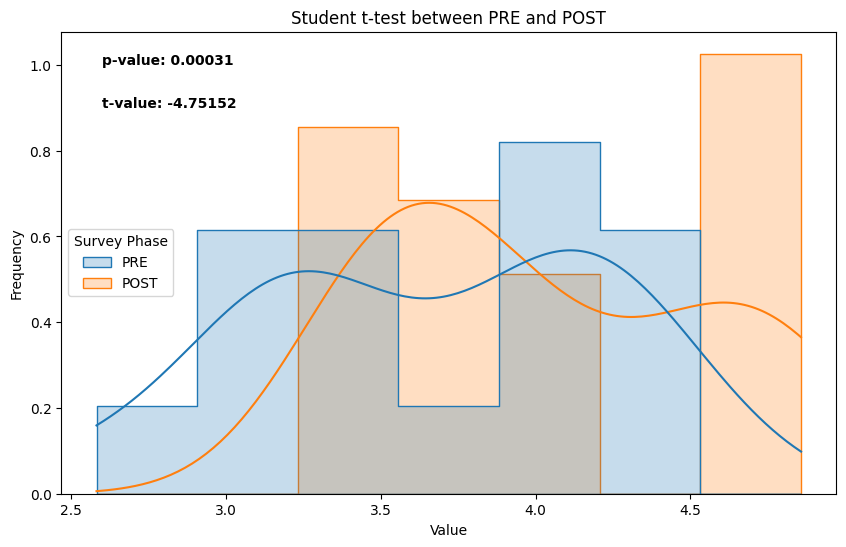

In [9]:
groupA = T_DATA['PRE']
groupB = T_DATA['POST']
t_statistic, p_value  = stats.ttest_rel(groupA, groupB, nan_policy='omit')
p_value = round(p_value,5) # more decimal since it's a lower value in general
t_value = round(t_statistic,5)
mean_groupA = groupA.mean()
mean_groupB = groupB.mean()
group_name = T_DATA.index.tolist()
# Get group names and define colors
# Init plots
df = pd.DataFrame({'PRE': groupA, 'POST': groupB})
# Melt the DataFrame to long format for Seaborn
df_long = df.melt(var_name='Survey Phase', value_name='Value')
# 2. Plot with KDE (Kernel Density Estimate)
plt.figure(figsize=(10, 6))
ax = sns.histplot(data=df_long, x='Value', hue='Survey Phase', element="step", kde=True, stat="density", common_norm=False)
plt.title("Overlapping Histograms with Density Curves")
# Add the p value and the t
p_value_text = f'p-value: {p_value}'
ax.text(2.6, 1, p_value_text, weight='bold')
t_value_text = f't-value: {t_value}'
ax.text(2.6, 0.9, t_value_text, weight='bold')
# Add a title and axis label
ax.set_title('Student t-test between PRE and POST')
ax.set_xlabel('Value')
ax.set_ylabel('Frequency')
# Show the plot
plt.show()

Clustered column chart from Concept ~ Phase using Numeric Response

c:\Users\gabri\anaconda3\Lib\site-packages\dfply\base.py:309: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dff = grouped.apply(self.function, *args, **kwargs)


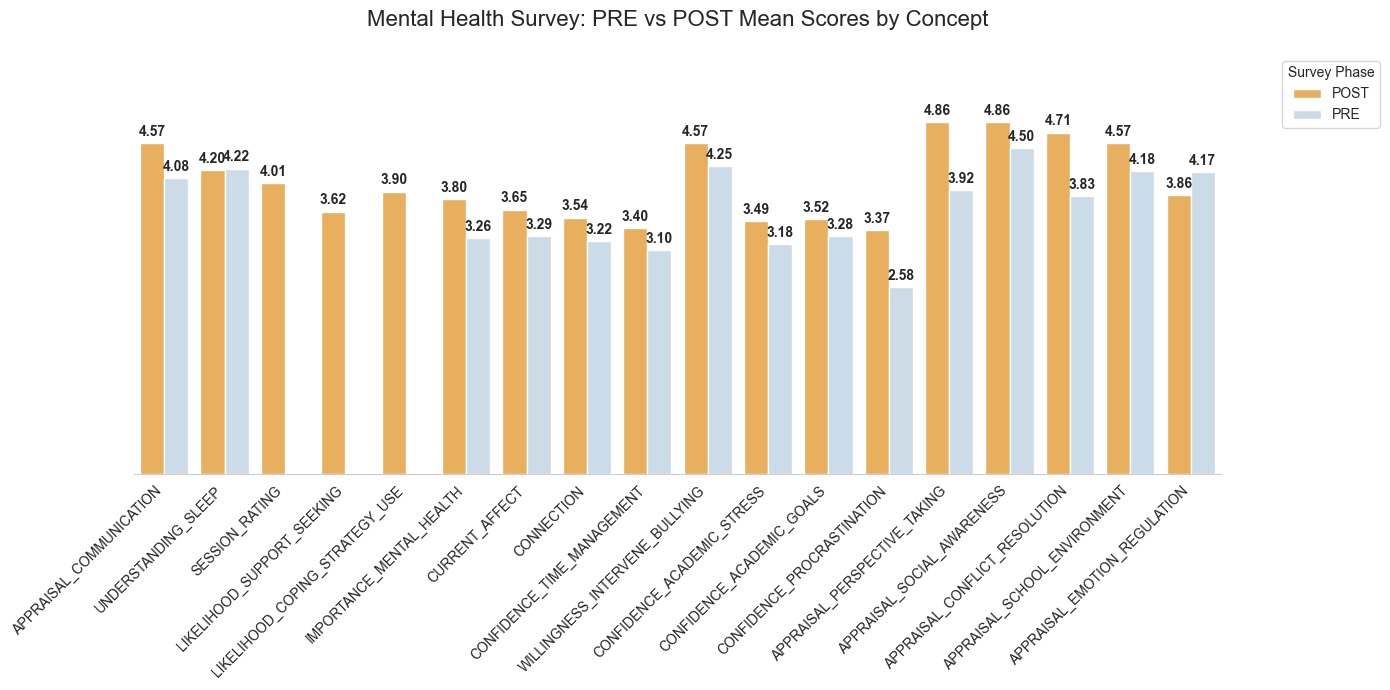

In [10]:
# Calculate the mean score per Concept and Phase
df = (RESPONSES >> select(X.CONCEPT_NAME, X.SURVEY_PHASE, X.NUMERIC_RESPONSE) >> transmute(CONCEPT = X.CONCEPT_NAME, PHASE = X.SURVEY_PHASE, RESPONSE = X.NUMERIC_RESPONSE)) 
df = df.dropna() >> mask(X.PHASE.isin(['PRE', 'POST']))
df = (df >> group_by(X.CONCEPT, X.PHASE) >> summarize(RESPONSE = mean(X.RESPONSE)) >> ungroup() >> arrange(X.PHASE, ascending=True))
# Create the Clustered Column Chart
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")
chart = sns.barplot(data=df,x='CONCEPT',y='RESPONSE',hue='PHASE',palette={'PRE': "#c6dcec", 'POST': '#ffb347'}) # Light Blue for PRE, Orange for POST
# Styling and Labels
for container in chart.containers:
    chart.bar_label(container,fmt='%.2f',padding=3,fontsize=10,fontweight='bold'    )
# Styling and Labels
plt.title('Mental Health Survey: PRE vs POST Mean Scores by Concept', fontsize=16, pad=20)
plt.xlabel('')
plt.ylabel('')
plt.yticks([])       # Removes the Y-axis numbers and tick marks
sns.despine(left=True)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 5.8)  # Increased slightly to make room for labels above the bars
plt.legend(title='Survey Phase', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('clustered_column_chart.png')

Clustered column chart from School Id ~ Phase using Numeric Response

c:\Users\gabri\anaconda3\Lib\site-packages\dfply\base.py:309: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dff = grouped.apply(self.function, *args, **kwargs)


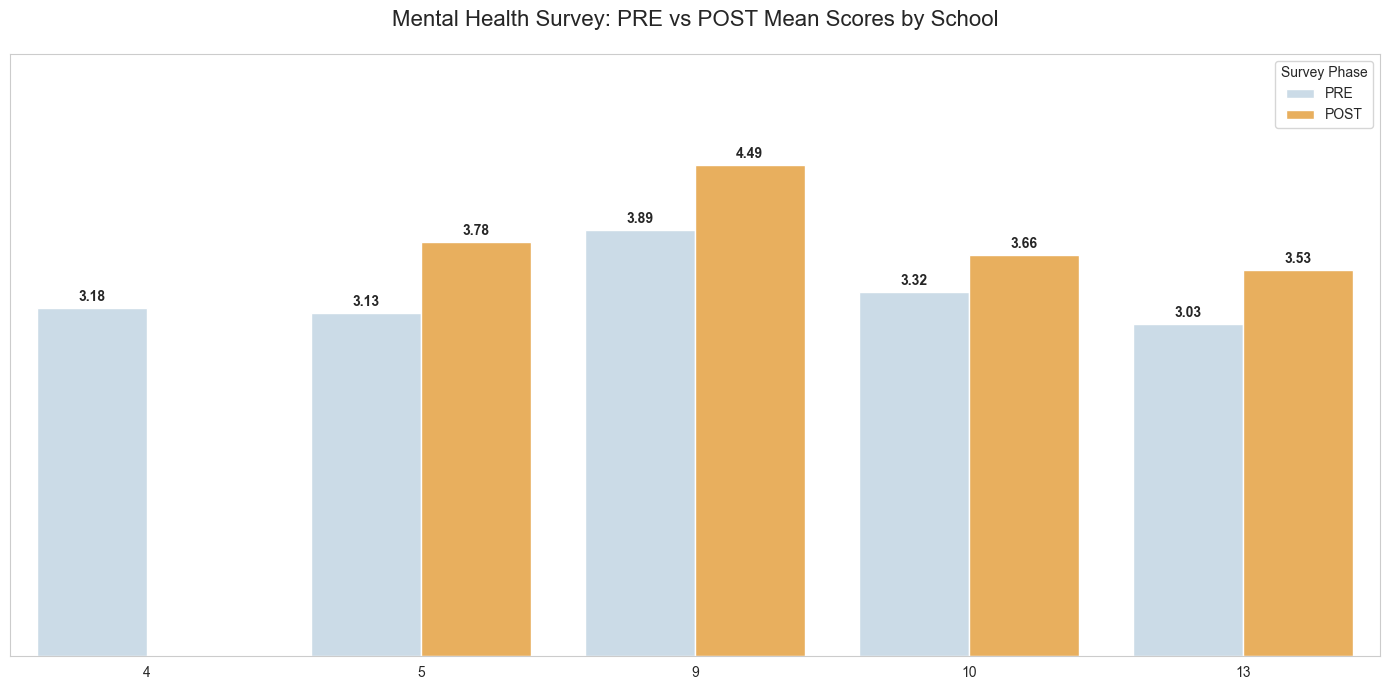

In [11]:
# Calculate the mean score per Concept and Phase
df = (RESPONSES >> select(X.SCHOOL_ID, X.SURVEY_PHASE, X.NUMERIC_RESPONSE) >> transmute(SCHOOL= X.SCHOOL_ID, PHASE = X.SURVEY_PHASE, RESPONSE = X.NUMERIC_RESPONSE)) 
df = df.dropna() >> mask(X.PHASE.isin(['PRE', 'POST']))
df = (df >> group_by(X.SCHOOL, X.PHASE) >> summarize(RESPONSE = mean(X.RESPONSE)) >> ungroup() >> arrange(X.PHASE, ascending=True))
# Create the Clustered Column Chart
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")
chart = sns.barplot(data=df,x='SCHOOL',y='RESPONSE',hue='PHASE',palette={'PRE': "#c6dcec", 'POST': '#ffb347'}) # Light Blue for PRE, Orange for POST
for container in chart.containers:
    chart.bar_label(container,fmt='%.2f',padding=3,fontsize=10,fontweight='bold'    )
# Styling and Labels
plt.title('Mental Health Survey: PRE vs POST Mean Scores by School', fontsize=16, pad=20)
plt.xlabel('')
plt.ylabel('')
plt.yticks([])  
plt.ylim(0, 5.5) # Since the scale is 1-5
plt.legend(title='Survey Phase')
plt.tight_layout()
plt.savefig('clustered_column_chart.png')

Line Chart using the Year and Month ~ Phase

c:\Users\gabri\anaconda3\Lib\site-packages\dfply\base.py:309: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dff = grouped.apply(self.function, *args, **kwargs)


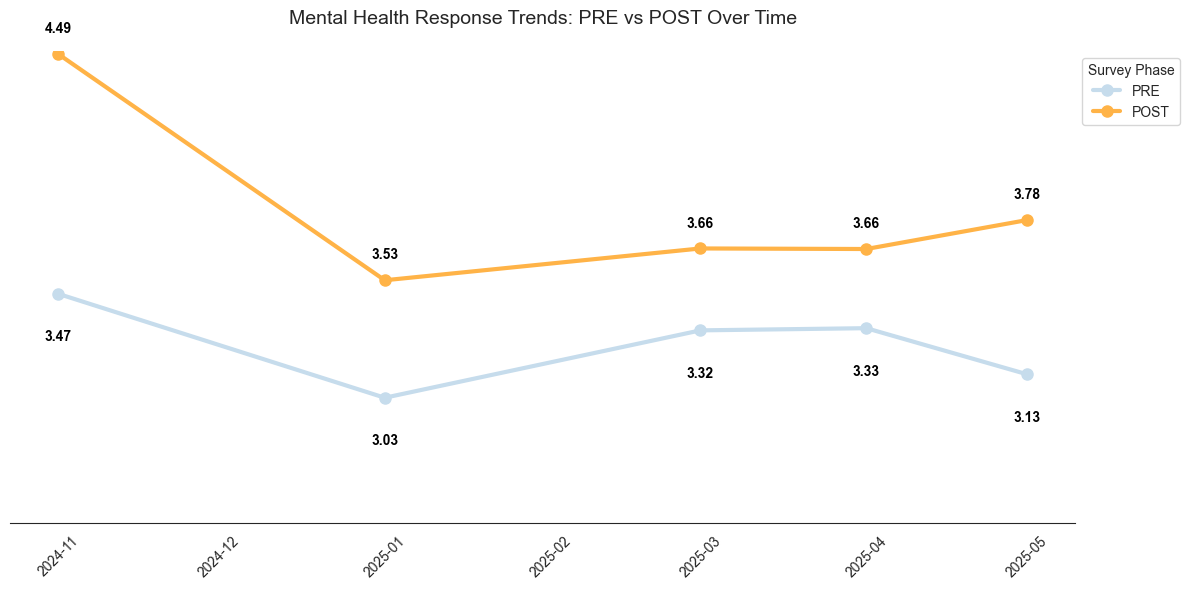

In [12]:
# Calculate the mean score per Concept and Phase
df = (RESPONSES >> select(X.YEAR_MONTH, X.SURVEY_PHASE, X.NUMERIC_RESPONSE) >> transmute(DATE= X.YEAR_MONTH, PHASE = X.SURVEY_PHASE, RESPONSE = X.NUMERIC_RESPONSE)) 
df = df.dropna() >> mask(X.PHASE.isin(['PRE', 'POST']))
df = (df >> group_by(X.DATE, X.PHASE) >> summarize(RESPONSE = mean(X.RESPONSE)) >> ungroup() >> arrange(X.PHASE, ascending=True))
# Sort by Date
df['DATE'] = pd.to_datetime(df['DATE'])
df = df.sort_values(by=['DATE', 'PHASE'])
palette = {'PRE': "#c6dcec", 'POST': '#ffb347'}
plt.figure(figsize=(12, 6))
sns.set_style("white") 
palette = {'PRE': "#c6dcec", 'POST': '#ffb347'}
for phase in ['PRE', 'POST']:
    subset = df[df['PHASE'] == phase]
    # Plot the line
    plt.plot(subset['DATE'],subset['RESPONSE'],marker='o',linestyle='-',linewidth=3,markersize=8,color=palette[phase],label=phase)
    # Add labels for EVERY point on BOTH lines
    for x, y in zip(subset['DATE'], subset['RESPONSE']):
        # Offset logic: POST labels go slightly above, PRE labels go slightly below
        offset = 0.08 if phase == 'POST' else -0.15
        plt.text(x, y + offset,f'{y:.2f}',ha='center',va='bottom' if phase == 'POST' else 'top',fontsize=10,fontweight='bold',color='black')
# ------------------
plt.title('Mental Health Response Trends: PRE vs POST Over Time', fontsize=14, pad=20)
plt.xlabel('')
plt.ylabel("")           
plt.yticks([])           
plt.xticks(rotation=45)
sns.despine(left=True, bottom=False) # Removes left Y-axis line
plt.grid(False)
plt.legend(title='Survey Phase', loc='upper left', bbox_to_anchor=(1, 1))
plt.ylim(2.5, 4.5) # Adjust based on your specific data range
plt.tight_layout()
plt.show()

Chi square test of independence between Concept and Survey Phase

In [14]:
df = (RESPONSES >> select(X.CONCEPT_NAME, X.SURVEY_PHASE) >> transmute(CONCEPT = X.CONCEPT_NAME, PHASE = X.SURVEY_PHASE)) 
df = df.dropna() >> mask(X.PHASE.isin(['PRE', 'POST']))
# Create the contingency table
contingency_table = pd.crosstab(df['CONCEPT'], df['PHASE'])
# Perform the test
chi2_statistic, p_value, degrees_of_freedom, expected_frequencies = chi2_contingency(contingency_table if 'contingency_table' in locals() else observed)
# Print the results
print("Contingency Table:")
print(contingency_table)
print(f"\nChi-square statistic: {chi2_statistic:.5f}")
print(f"P-value: {p_value:.5f}")
print(f"Degrees of freedom: {degrees_of_freedom}")
print("Expected frequencies:\n", expected_frequencies)
alpha = 0.05
if p_value < alpha:
    print(f"\nConclusion: Reject the null hypothesis. There is a significant association between the two variables (p < {alpha}).")
else:
    print(f"\nConclusion: Fail to reject the null hypothesis. There is no significant association between the two variables (p >= {alpha}).")

Contingency Table:
PHASE                           POST  PRE
CONCEPT                                  
APPRAISAL_COMMUNICATION            7   12
APPRAISAL_CONFLICT_RESOLUTION      7   12
APPRAISAL_EMOTION_REGULATION       7   12
APPRAISAL_PERSPECTIVE_TAKING       7   12
APPRAISAL_SCHOOL_ENVIRONMENT       7   11
APPRAISAL_SOCIAL_AWARENESS         7   12
CONFIDENCE_ACADEMIC_GOALS        151  235
CONFIDENCE_ACADEMIC_STRESS       150  235
CONFIDENCE_PROCRASTINATION       151  235
CONFIDENCE_TIME_MANAGEMENT       151  235
CONNECTION                       157  245
CURRENT_AFFECT                   158  247
IMPORTANCE_MENTAL_HEALTH         151  234
LIKELIHOOD_COPING_STRATEGY_USE   150    0
LIKELIHOOD_SUPPORT_SEEKING       149    0
SESSION_RATING                   157    0
UNDERSTANDING_SLEEP              148  230
WILLINGNESS_INTERVENE_BULLYING     7   12

Chi-square statistic: 597.92978
P-value: 0.00000
Degrees of freedom: 17
Expected frequencies:
 [[  8.84031343  10.15968657]
 [  8.84031343  